# Exploratory Data Analysis on Retail Sales Data

## Introduction

This project focuses on performing Exploratory Data Analysis (EDA) on a retail sales dataset.

The objective is to understand sales trends, customer demographics, product category performance, and relationships between numerical variables.

Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn are used for data processing, statistical analysis, and visualization.

The analysis aims to convert raw retail sales data into meaningful insights that can support data-driven business decisions.

## Tools and Technologies

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Dataset

The dataset contains retail transaction information including:

- Transaction ID
- Date
- Customer ID
- Gender
- Age
- Product Category
- Quantity
- Price per Unit
- Total Amount

## Dataset Information

The dataset used in this project contains retail transaction records.

The main attributes include:

- Transaction ID – Unique identifier for each transaction
- Date – Date of the transaction
- Customer ID – Unique customer identifier
- Gender – Customer gender
- Age – Customer age
- Product Category – Category of the purchased product
- Quantity – Number of units purchased
- Price per Unit – Price of one unit
- Total Amount – Total transaction amount

The dataset is analyzed to identify sales trends, customer purchasing patterns, and product category performance.

## Objectives

The main objectives of this project are:

1. To understand the structure and quality of the retail sales dataset.
2. To analyze monthly and quarterly sales trends.
3. To understand customer purchasing behaviour based on gender and age groups.
4. To identify high-performing and low-performing product categories.
5. To examine relationships between numerical variables using correlation analysis.
6. To generate meaningful business insights and recommendations from the analysis.

## EDA Methodology

The following steps were followed during the analysis:

1. Data loading
2. Data inspection
3. Data quality checking
4. Descriptive statistical analysis
5. Date-based analysis
6. Customer demographic analysis
7. Product category analysis
8. Correlation analysis
9. Data visualization
10. Business insight generation
11. Recommendations and conclusion

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [4]:
df = pd.read_csv('retail_sales_dataset.csv')

In [5]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
df.shape

(1000, 9)

In [18]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [9]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [12]:
df.mean(numeric_only=True)

,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


In [13]:
df.median(numeric_only=True)

,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [14]:
df.mode(numeric_only=True).iloc[0]

,0
Transaction ID,1.0
Age,43.0
Quantity,4.0
Price per Unit,50.0
Total Amount,50.0


In [15]:
df.std(numeric_only=True)

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


In [16]:
stats = pd.DataFrame({
    'Mean': df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mean(),
    'Median': df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].median(),
    'Mode': df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mode().iloc[0],
    'Standard Deviation': df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].std()
})

stats

,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [19]:
df['Date'] = pd.to_datetime(df['Date'])

In [20]:
df['Date'].dtype

dtype('<M8[ns]')

In [21]:
df['Month'] = df['Date'].dt.to_period('M')

In [22]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales

,Total Amount
Month,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


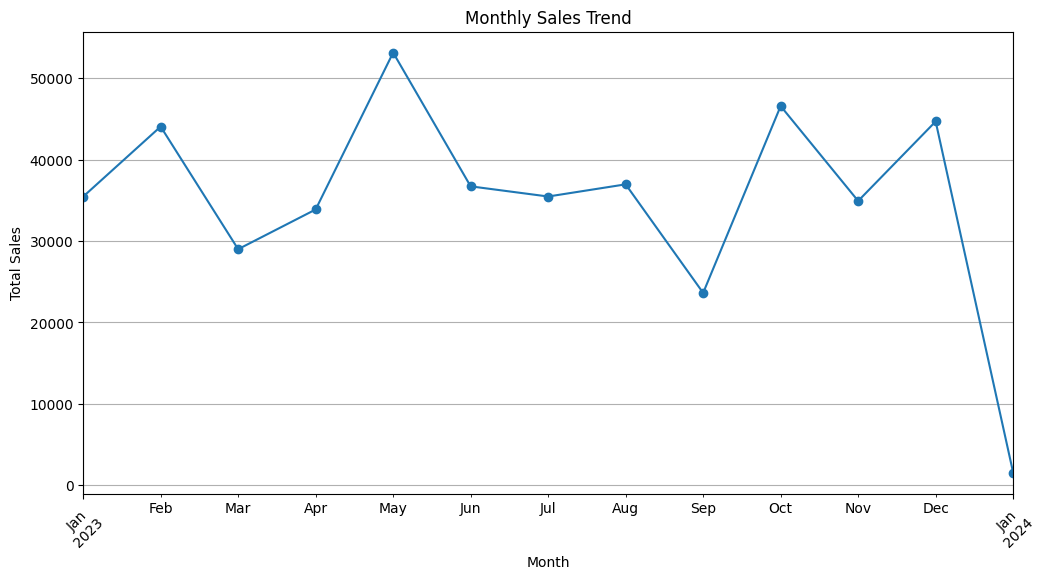

In [23]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation – Monthly Sales Trend

The monthly sales trend shows considerable variation in sales throughout 2023. May recorded the highest monthly sales, with sales of approximately ₹53,000. October and December also showed relatively strong sales performance.

September recorded the lowest sales among the complete months of 2023, at approximately ₹24,000. Overall, the sales trend does not show a continuous increase or decrease, but instead fluctuates across different months.

The small value shown for January 2024 is due to the dataset containing only a limited number of transactions for that month, so it should not be directly compared with the complete months of 2023.

In [24]:
df['Quarter'] = df['Date'].dt.to_period('Q')

In [25]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales

,Total Amount
Quarter,
2023Q1,108500
2023Q2,123735
2023Q3,96045
2023Q4,126190
2024Q1,1530


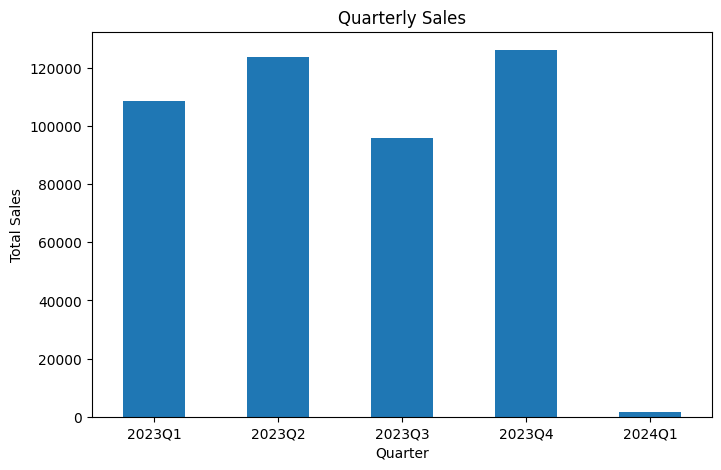

In [26]:
plt.figure(figsize=(8, 5))

quarterly_sales.plot(kind='bar')

plt.title('Quarterly Sales')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

### Observation – Quarterly Sales

The quarterly analysis shows that sales varied across the four quarters of 2023. Q4 recorded the highest total sales, followed closely by Q2, while Q3 recorded the lowest sales among the complete quarters of 2023.

The small value shown for Q1 2024 is due to a transaction recorded on January 1, 2024. Since Q1 2024 is incomplete in the dataset, it should not be directly compared with the complete quarters of 2023.

In [27]:
gender_counts = df['Gender'].value_counts()

gender_counts

,count
Gender,
Female,510
Male,490


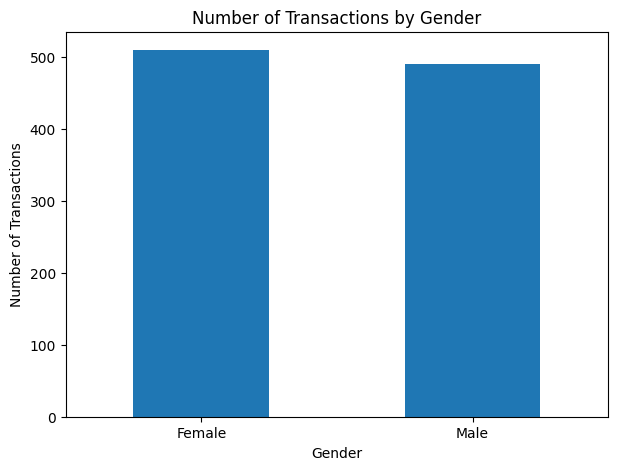

In [28]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Number of Transactions by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.show()

In [29]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

,Total Amount
Gender,
Female,232840
Male,223160


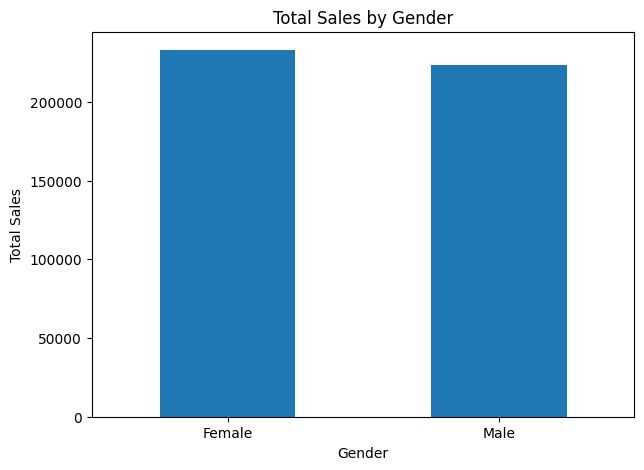

In [30]:
plt.figure(figsize=(7, 5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

In [31]:
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [32]:
df[['Age', 'Age Group']].head(10)

,Age,Age Group
0,34,26-35
1,26,26-35
2,50,46-55
3,37,36-45
4,30,26-35
5,45,36-45
6,46,46-55
7,30,26-35
8,63,56-65
9,52,46-55


In [33]:
age_group_counts = df['Age Group'].value_counts().sort_index()

age_group_counts

,count
Age Group,
18-25,169
26-35,205
36-45,202
46-55,229
56-65,195


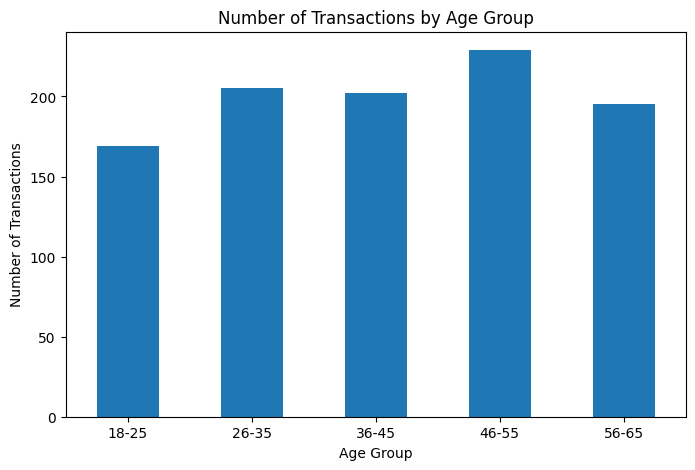

In [34]:
plt.figure(figsize=(8, 5))

age_group_counts.plot(kind='bar')

plt.title('Number of Transactions by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.show()

In [35]:
age_group_sales = df.groupby('Age Group', observed=True)['Total Amount'].sum()

age_group_sales

,Total Amount
Age Group,
18-25,84550
26-35,98480
36-45,91870
46-55,100690
56-65,80410


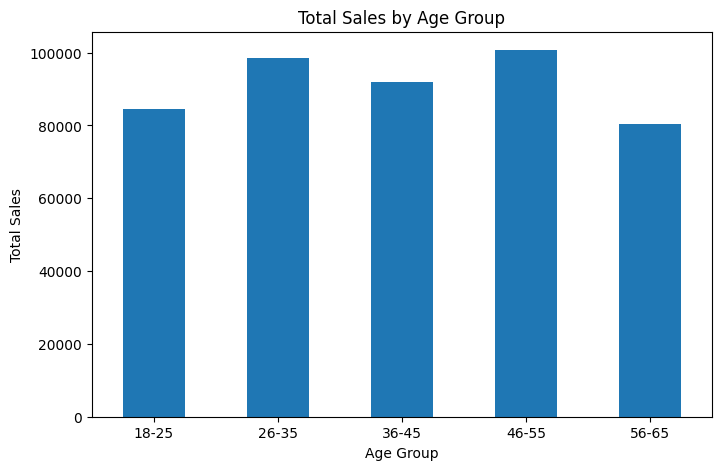

In [36]:
plt.figure(figsize=(8, 5))

age_group_sales.plot(kind='bar')

plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

### Observation – Customer Age Groups

The age-group analysis shows the distribution of transactions across different customer age ranges. It helps identify the age group with the highest number of transactions.

The sales analysis further shows the total revenue generated by each age group. Comparing transaction volume with total sales helps identify the customer groups that contribute most to the business revenue.

In [37]:
category_counts = df['Product Category'].value_counts()

category_counts

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


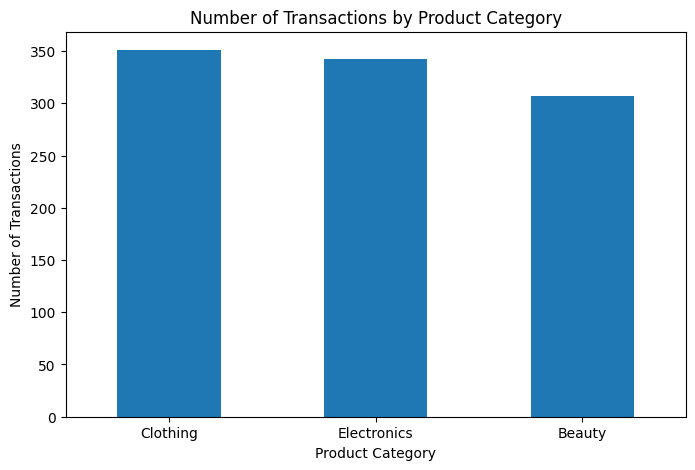

In [38]:
plt.figure(figsize=(8, 5))

category_counts.plot(kind='bar')

plt.title('Number of Transactions by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.show()

In [39]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


## 6. Product Category Analysis

Product category analysis is performed to understand the sales performance and transaction volume of different product categories. The analysis helps identify categories that contribute significantly to overall revenue.

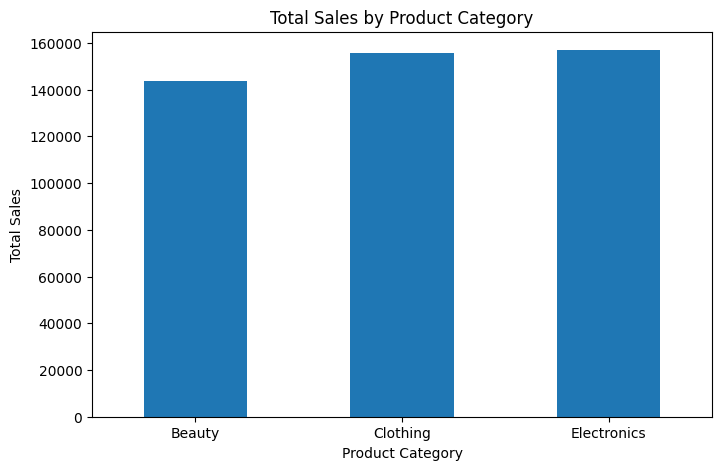

In [40]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

### Observation – Product Category Analysis

The product category analysis compares the number of transactions and total sales generated by each category. The results help identify the most frequently purchased categories and the categories that contribute the highest revenue.

In [41]:
category_percentage = (category_sales / category_sales.sum()) * 100

category_percentage

,Total Amount
Product Category,
Beauty,31.472588
Clothing,34.118421
Electronics,34.408991


In [42]:
category_summary = pd.DataFrame({
    'Transactions': category_counts,
    'Total Sales': category_sales,
    'Sales Percentage': category_percentage
})

category_summary

,Transactions,Total Sales,Sales Percentage
Product Category,,,
Beauty,307,143515,31.472588
Clothing,351,155580,34.118421
Electronics,342,156905,34.408991


## 7. Correlation Analysis

Correlation analysis is used to examine the linear relationships between numerical variables in the retail sales dataset. Age, Quantity, Price per Unit, and Total Amount are considered for this analysis.

A correlation coefficient ranges from -1 to +1. Positive values indicate a positive relationship, negative values indicate a negative relationship, and values close to zero indicate a weak linear relationship.

In [43]:
correlation_matrix = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
].corr()

correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


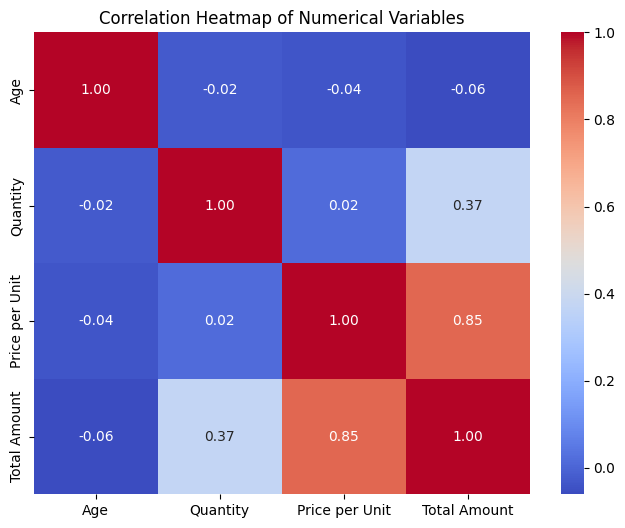

In [44]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Observation – Correlation Analysis

The correlation heatmap shows the relationships between the numerical variables in the dataset. The relationships between Quantity, Price per Unit, and Total Amount are particularly relevant for understanding transaction values.

The results represent associations between variables and should not be interpreted as proof of causation.

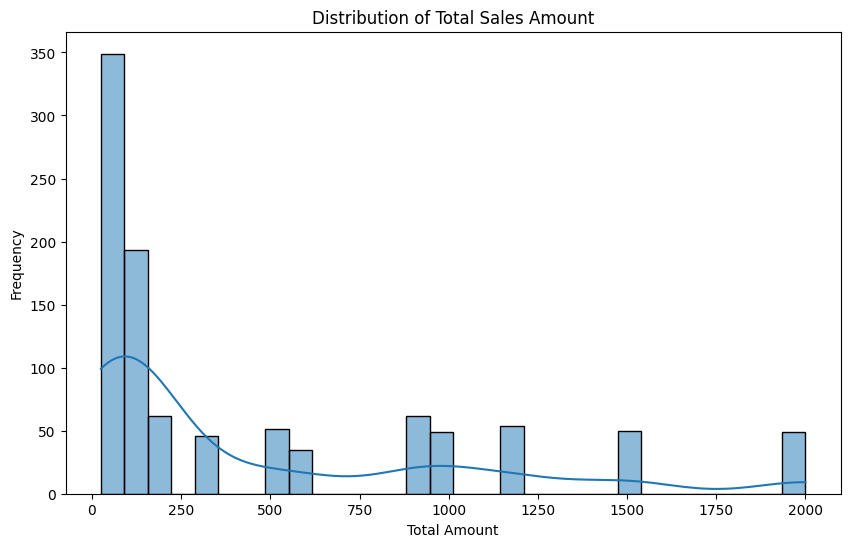

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Total Amount'], bins=30, kde=True)

plt.title('Distribution of Total Sales Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')

plt.show()

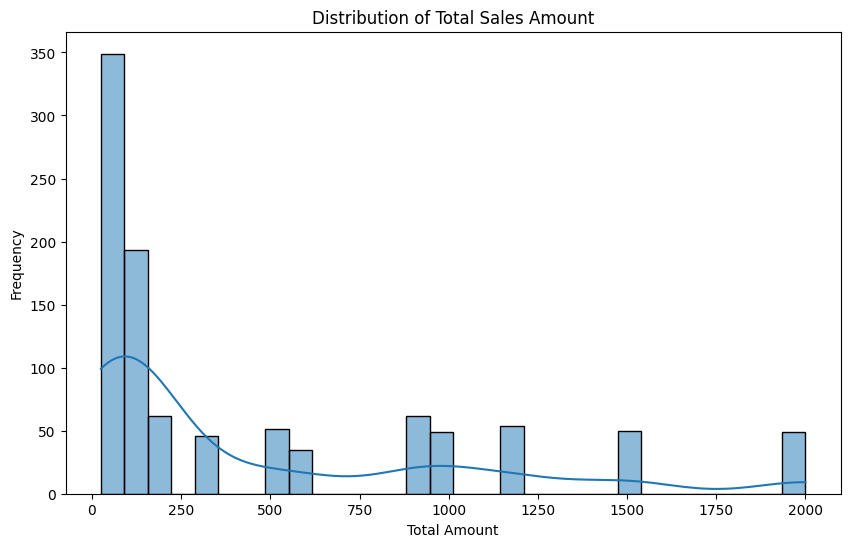

In [46]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Total Amount'], bins=30, kde=True)

plt.title('Distribution of Total Sales Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')

plt.show()

In [47]:
gender_percentage = (
    df.groupby('Gender')['Total Amount'].sum()
    / df['Total Amount'].sum()
) * 100

gender_percentage

,Total Amount
Gender,
Female,51.061404
Male,48.938596


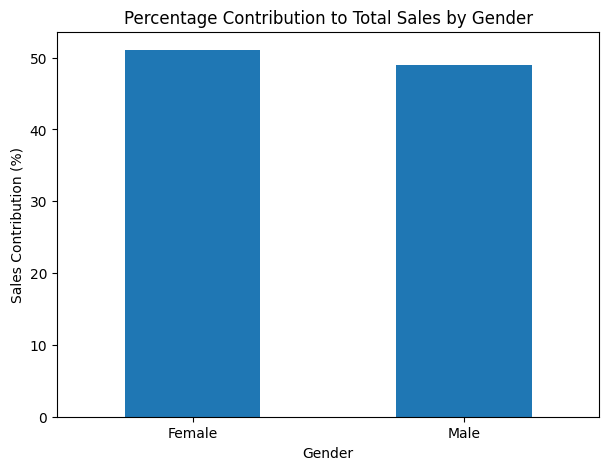

In [48]:
plt.figure(figsize=(7, 5))

gender_percentage.plot(kind='bar')

plt.title('Percentage Contribution to Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Sales Contribution (%)')
plt.xticks(rotation=0)

plt.show()

In [49]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

worst_month = monthly_sales.idxmin()
worst_month_sales = monthly_sales.min()

print("Highest Sales Month:", best_month)
print("Highest Monthly Sales:", best_month_sales)

print("Lowest Sales Month:", worst_month)
print("Lowest Monthly Sales:", worst_month_sales)

Highest Sales Month: 2023-05
Highest Monthly Sales: 53150
Lowest Sales Month: 2024-01
Lowest Monthly Sales: 1530


In [50]:
best_quarter = quarterly_sales.idxmax()
best_quarter_sales = quarterly_sales.max()

print("Highest Sales Quarter:", best_quarter)
print("Highest Quarterly Sales:", best_quarter_sales)

Highest Sales Quarter: 2023Q4
Highest Quarterly Sales: 126190


In [51]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

lowest_category = category_sales.idxmin()
lowest_category_sales = category_sales.min()

print("Highest Sales Category:", best_category)
print("Highest Category Sales:", best_category_sales)

print("Lowest Sales Category:", lowest_category)
print("Lowest Category Sales:", lowest_category_sales)

Highest Sales Category: Electronics
Highest Category Sales: 156905
Lowest Sales Category: Beauty
Lowest Category Sales: 143515


In [52]:
most_active_age_group = age_group_counts.idxmax()
most_active_age_transactions = age_group_counts.max()

print("Most Active Age Group:", most_active_age_group)
print("Number of Transactions:", most_active_age_transactions)

Most Active Age Group: 46-55
Number of Transactions: 229


In [53]:
best_age_sales_group = age_group_sales.idxmax()
best_age_sales = age_group_sales.max()

print("Highest Revenue Age Group:", best_age_sales_group)
print("Sales:", best_age_sales)

Highest Revenue Age Group: 46-55
Sales: 100690


In [54]:
best_gender = gender_sales.idxmax()
best_gender_sales = gender_sales.max()

print("Gender with Highest Sales:", best_gender)
print("Sales:", best_gender_sales)

Gender with Highest Sales: Female
Sales: 232840


In [55]:
insights_summary = pd.DataFrame({
    'Metric': [
        'Highest Sales Month',
        'Lowest Sales Month',
        'Highest Sales Quarter',
        'Highest Sales Category',
        'Lowest Sales Category',
        'Most Active Age Group',
        'Highest Revenue Age Group',
        'Highest Sales Gender'
    ],
    'Result': [
        best_month,
        worst_month,
        best_quarter,
        best_category,
        lowest_category,
        most_active_age_group,
        best_age_sales_group,
        best_gender
    ]
})

insights_summary

,Metric,Result
0,Highest Sales Month,2023-05
1,Lowest Sales Month,2024-01
2,Highest Sales Quarter,2023Q4
3,Highest Sales Category,Electronics
4,Lowest Sales Category,Beauty
5,Most Active Age Group,46-55
6,Highest Revenue Age Group,46-55
7,Highest Sales Gender,Female


## 8. Key Business Insights

The exploratory data analysis produced the following key insights:

1. **Monthly Sales Performance:** Sales varied across the months, with noticeable differences between the highest and lowest performing months.

2. **Quarterly Sales Performance:** The quarterly analysis identified the strongest-performing quarter, helping understand the periods of higher business activity.

3. **Product Category Performance:** The analysis identified the product category generating the highest sales and the category with the lowest sales contribution.

4. **Customer Age Group:** The age-group analysis identified the age group with the highest number of transactions and the age group generating the highest revenue.

5. **Gender Analysis:** The gender analysis showed which customer group contributed the highest total sales.

6. **Sales Distribution:** The distribution analysis showed how transaction amounts are spread across the dataset.

7. **Variable Relationships:** The correlation analysis showed the relationships between Age, Quantity, Price per Unit, and Total Amount.

In [56]:
print("KEY BUSINESS INSIGHTS")
print("-" * 40)

print(f"Highest Sales Month: {best_month}")
print(f"Sales: {best_month_sales:,.2f}")

print(f"\nLowest Sales Month: {worst_month}")
print(f"Sales: {worst_month_sales:,.2f}")

print(f"\nHighest Sales Quarter: {best_quarter}")
print(f"Sales: {best_quarter_sales:,.2f}")

print(f"\nHighest Sales Category: {best_category}")
print(f"Sales: {best_category_sales:,.2f}")

print(f"\nLowest Sales Category: {lowest_category}")
print(f"Sales: {lowest_category_sales:,.2f}")

print(f"\nMost Active Age Group: {most_active_age_group}")
print(f"Transactions: {most_active_age_transactions}")

print(f"\nHighest Revenue Age Group: {best_age_sales_group}")
print(f"Sales: {best_age_sales:,.2f}")

print(f"\nHighest Sales Gender: {best_gender}")
print(f"Sales: {best_gender_sales:,.2f}")

KEY BUSINESS INSIGHTS
----------------------------------------
Highest Sales Month: 2023-05
Sales: 53,150.00

Lowest Sales Month: 2024-01
Sales: 1,530.00

Highest Sales Quarter: 2023Q4
Sales: 126,190.00

Highest Sales Category: Electronics
Sales: 156,905.00

Lowest Sales Category: Beauty
Sales: 143,515.00

Most Active Age Group: 46-55
Transactions: 229

Highest Revenue Age Group: 46-55
Sales: 100,690.00

Highest Sales Gender: Female
Sales: 232,840.00


## 9. Business Recommendations

Based on the findings from the exploratory data analysis, the following recommendations are suggested:

### 1. Focus on High-Performing Product Categories
The business should maintain sufficient inventory and promotional support for the categories generating the highest sales.

### 2. Improve Low-Performing Categories
The lowest-performing categories should be reviewed to understand customer preferences. Discounts, product improvements, or targeted promotions can be considered to improve their performance.

### 3. Use Customer Segmentation
Marketing campaigns can be targeted toward the age groups and gender segments contributing significantly to sales.

### 4. Plan for High-Sales Periods
Historical monthly and quarterly trends can be used to plan inventory, staffing, and promotional campaigns before high-sales periods.

### 5. Monitor Sales Trends Regularly
The business should periodically analyze sales data to identify changes in customer behaviour and product performance and make data-driven decisions.

## 10. Conclusion

This exploratory data analysis provided a detailed understanding of the retail sales dataset by examining sales trends, customer demographics, product categories, transaction amounts, and relationships between numerical variables.

The analysis identified variations in monthly and quarterly sales, differences in customer purchasing behaviour across age groups and genders, and differences in product category performance.

The visualizations and statistical analysis helped transform the raw retail dataset into meaningful business insights. These insights can support better inventory planning, customer targeting, promotional strategies, and overall data-driven decision making.

Overall, this project demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used to perform exploratory data analysis and generate useful business insights from retail sales data.

In [57]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,2023Q4,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,2023Q1,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,2023Q1,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2023Q2,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2023Q2,26-35


In [58]:
df.shape

(1000, 12)

In [59]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0
Month,0


In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.to_csv('retail_sales_analysis_completed.csv', index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


## Project Summary

This project demonstrates the complete Exploratory Data Analysis process using a retail sales dataset.

The analysis covered data inspection, data quality checking, statistical analysis, sales trend analysis, customer demographic analysis, product category analysis, correlation analysis, and visualization.

The final insights provide a better understanding of customer behaviour and sales performance and can help support data-driven business decisions.